In [1]:
import cv2 
import glob
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf

TESTING FILTERS FOR IMAGES

In [2]:
## training images 
train_images = []
test_array = []


# ##testing images 
# test_malignant_images =[]
# test_benign_images = []


In [ ]:
for file in glob.glob('C:/Users/sachi/Downloads/detection_model/breast_mri_dataset/train/Malignant/*.jpg'):
    if file is not None:
        train_images.append(cv2.imread(file))
        test_array.append(1)

for file in glob.glob('C:/Users/sachi/Downloads/detection_model/breast_mri_dataset/train/Benign/*.jpg'):
    if file is not None:
        train_images.append(cv2.imread(file))
        test_array.append(0)



<function matplotlib.pyplot.show(close=None, block=None)>

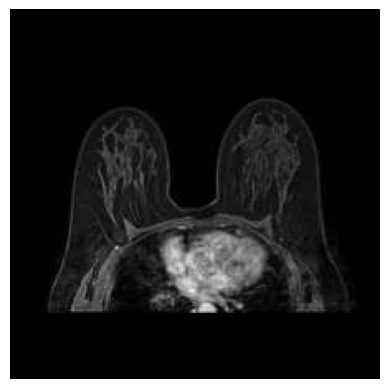

In [ ]:
img1 = train_images[100]
img_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show

In [5]:
train_images[100].shape

(224, 224, 3)

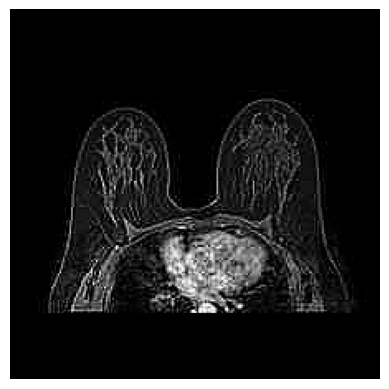

In [6]:
img1 = train_images[100]

kernel = np.array([ [0, -1, 0], 
                    [-1, 5, -1], 
                    [0, -1, 0]], dtype=np.float32)
sharpend_image = cv2.filter2D(
    img1, 
    ddepth=-1, 
    kernel=kernel, 
    anchor=(-1, -1), 
    delta=0, 
    borderType=cv2.BORDER_DEFAULT)

plt.imshow(sharpend_image)
plt.axis('off')
plt.show()

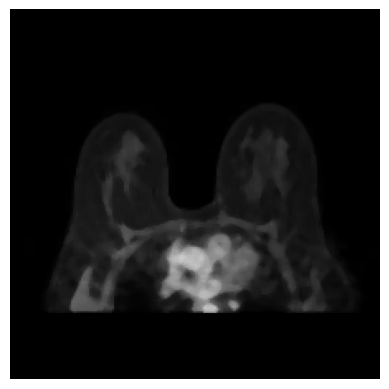

In [7]:
img2 = train_images[58]

img2_reduce_blur = cv2.medianBlur(img2, 5)

plt.imshow(img2_reduce_blur)
plt.axis('off')
plt.show()

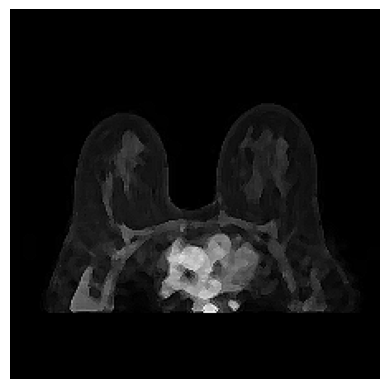

In [8]:
img2_reduce_blur = cv2.filter2D(
    img2_reduce_blur, 
    ddepth=-1, 
    kernel=kernel, 
    anchor=(-1, -1), 
    delta=0, 
    borderType=cv2.BORDER_DEFAULT)

plt.imshow(img2_reduce_blur)
plt.axis('off')
plt.show()

APPLYING FILTERING TO ALL PICTURES

Applied Filtering to all images in Dataset.


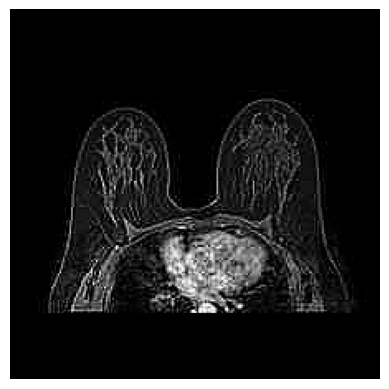

In [9]:
filtered_train_images = []


for i in range(len(train_images)):
    train_images[i] = cv2.filter2D(
        train_images[i], 
        ddepth=-1, 
        kernel=kernel, 
        anchor=(-1, -1), 
        delta=0, 
        borderType=cv2.BORDER_DEFAULT
    )
    filtered_train_images.append(train_images[i])

# for i in range(len(train_benign_dataset)):
#     train_benign_dataset[i] = cv2.filter2D(
#         train_benign_dataset[i], 
#         ddepth=-1, 
#         kernel=kernel, 
#         anchor=(-1, -1), 
#         delta=0, 
#         borderType=cv2.BORDER_DEFAULT
#     )
#     filtered_benign_images.append(train_benign_dataset[i])


print("Applied Filtering to all images in Dataset.")
plt.imshow(filtered_train_images[100])
plt.axis('off')
plt.show()

ANALYSING IMAGE DATA - PREPROCESSING 

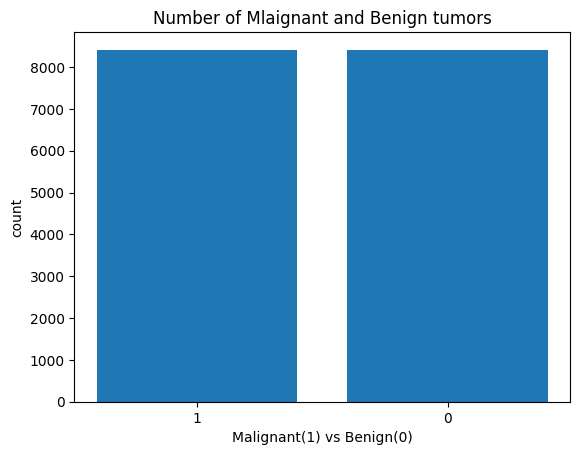

In [10]:
labels = test_array[ :]
counts = pd.Series(labels).value_counts()

fig, ax = plt.subplots()

ax.bar(counts.index.astype(str), counts.values)
ax.set_xlabel('Malignant(1) vs Benign(0)')
ax.set_ylabel('count')
ax.set_title('Number of Mlaignant and Benign tumors')

plt.show()

In [11]:
##verifying bar graph above 
train_labels = np.asarray(test_array)

x = np.sum(train_labels == 1)
x2 = np.sum(train_labels == 0)

x, x2

(np.int64(8413), np.int64(8413))

PREPROCESSING VALIDATION SET

In [12]:
val_images = []
val_labels = []

for file in glob.glob('C:/Users/sachi/Downloads/detection_model/breast_mri_dataset/val/Malignant/*.jpg'):
    if file is not None:
        val_images.append(cv2.imread(file))
        val_labels.append(1)

for file in glob.glob('C:/Users/sachi/Downloads/detection_model/breast_mri_dataset/val/Benign/*.jpg'):
    if file is not None:
        val_images.append(cv2.imread(file))
        val_labels.append(0)


In [13]:
val_array = []

for i in range(len(val_images)):
    val_images[i] = cv2.filter2D(
        val_images[i], 
        ddepth=-1, 
        kernel=kernel, 
        anchor=(-1, -1), 
        delta=0, 
        borderType=cv2.BORDER_DEFAULT
    )
    val_array.append(val_images[i])

In [14]:
X_train = np.asarray(filtered_train_images) 
Y_train = train_labels

X_val = np.asarray(val_array)
Y_val = np.asarray(val_labels)

CREATING AND TRAINING MODEL ON TRAINING AND VALODATION SET

In [ ]:
input_size = X_train[100].shape 
input_size 

(224, 224, 3)

In [16]:
model = tf.keras.Sequential([
    
    #Convolution Layers
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_size),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)), 

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)), 
    tf.keras.layers.Dropout(0.2), 

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'), 
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)), 

    #Flatten Extraction for Dense Layers
    tf.keras.layers.Flatten(),

    #Dense Layers
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation='relu'),

    #Ouput Layer => Outputs Binary Classification 0 or 1.
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\sachi\Downloads\detection_model\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,635,329 (21.50 MB)

 Trainable params: 5,635,329 (21.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', 
              loss= tf.keras.losses.BinaryCrossentropy(from_logits=False), 
              metrics=['accuracy'])

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

# # FITTING MODEL TO TRAINING AND VALIDATION DATA - MODEL TRAINING 

losses = model.fit(
    X_train, Y_train, 
    validation_data=(X_val, Y_val), 
    batch_size= 25,
    callbacks=[early_stop]
)

In [19]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# y_pred_probs = model.predict(X_val)
# y_pred = (y_pred_probs > 0.5).astype('int32')
# y_hat = Y_val

In [20]:
# cm = confusion_matrix(y_hat, y_pred)

# display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])
# # display_cm.plt(cmap=plt.cm.Blues)
# display_cm.plot()
# # plt.show()

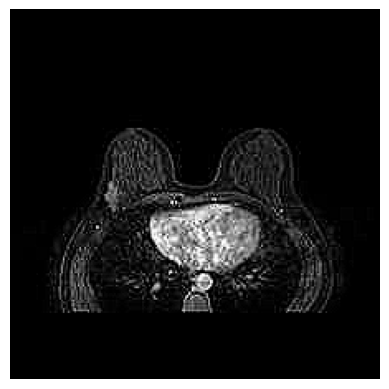

np.int64(1)

In [21]:
plt.imshow(X_val[165]) 
plt.axis('off')
plt.show()

Y_val[122]

In [22]:
# model.save("C:/Users/sachi/Downloads/detection_model/model.keras")

In [23]:
new_model = tf.keras.models.load_model("C:/Users/sachi/Downloads/detection_model/model.keras")

In [24]:
model_pred = new_model.predict(np.expand_dims(X_val[1789], axis=0))
prediction = (model_pred > 0.5).astype('int32')
prediction[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 972ms/step


np.int32(1)

PLOTTING ROC AUC CURVE TO OBSERVE MODEL BINARY CLASSIFICATION ACCURACY 

In [25]:
from sklearn.metrics import roc_curve, auc 

In [26]:
y_pred_prob = new_model.predict(X_val)

113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 294ms/step


In [27]:
# fpr, tpr, threshold = roc_curve(Y_val, y_pred_prob)
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" %roc_auc)
# plt.plot([0, 1], [0,1], color='blue', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC)')
# plt.legend(loc="lower right")
# plt.show()


LOADING IN TRAINING SET

In [28]:
test_images = []
test_labels = []

for file in glob.glob('C:/Users/sachi/Downloads/detection_model/breast_mri_dataset/test/Malignant/*.jpg'):
    if file is not None:
        test_images.append(cv2.imread(file))
        test_labels.append(1)

for file in glob.glob('C:/Users/sachi/Downloads/detection_model/breast_mri_dataset/test/Benign/*.jpg'):
    if file is not None:
        test_images.append(cv2.imread(file))
        test_labels.append(0)


In [29]:
# sharpening test set images 

filtered_test_images = []


for i in range(len(test_images)):
    test_images[i] = cv2.filter2D(
        test_images[i], 
        ddepth=-1, 
        kernel=kernel, 
        anchor=(-1, -1), 
        delta=0, 
        borderType=cv2.BORDER_DEFAULT
    )
    filtered_test_images.append(test_images[i])

In [30]:
len(filtered_test_images)

3604

------ PREDICTED VALUE--------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1
------ GROUND TRUTH VALUE--------
1


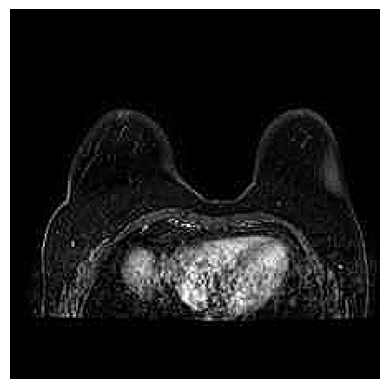

In [31]:
print('------ PREDICTED VALUE--------')
test_pred = new_model.predict(np.expand_dims(filtered_test_images[100], axis=0))
test_pred_convert = (test_pred > 0.5).astype('int32')
print(test_pred_convert[0][0])

print('------ GROUND TRUTH VALUE--------')
print(test_labels[100])
plt.imshow(filtered_test_images[100])
plt.axis('off')
plt.show()


In [32]:
#converting test set to numpy array for predictions
X_test = np.asarray(filtered_test_images)

In [33]:
#inference on test set
test_set_pred = new_model.predict(X_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 303ms/step


VISUALISING CNN PERFORMANCE ON TEST SET

In [34]:
y_test_pred = (test_set_pred > 0.5).astype('int32')
len(y_test_pred)

3604

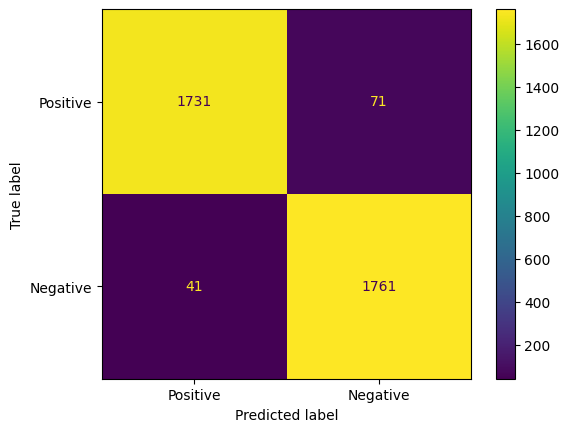

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_cm = confusion_matrix(test_labels, y_test_pred)

test_display_cm = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=['Positive', 'Negative'])
# display_cm.plt(cmap=plt.cm.Blues)
test_display_cm.plot()
# plt.show()

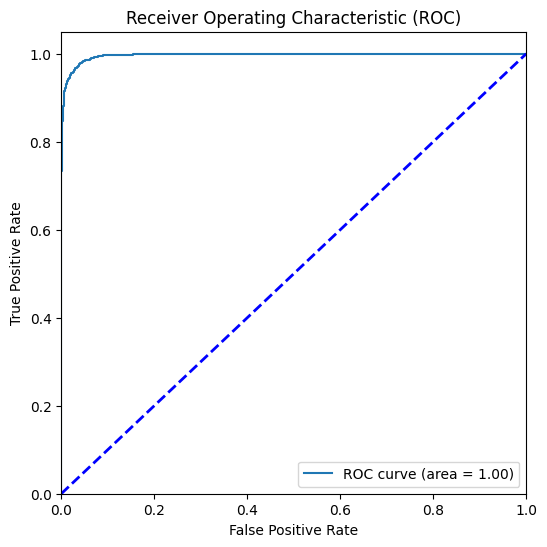

In [36]:
#ROC AUC curve

fpr, tpr, threshold = roc_curve(test_labels, test_set_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" %roc_auc)
plt.plot([0, 1], [0,1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [37]:
X_test_array = np.squeeze(X_test)
X_test_array.shape

Y_test = np.asarray(test_labels)
# test_loss, test_accuracy = new_model.evaluate(X_test, test_labels, verbose=2)

In [38]:
test_loss, test_accuracy = new_model.evaluate(X_test_array, Y_test, verbose=2)

113/113 - 35s - 310ms/step - accuracy: 0.9689 - loss: 0.0792


In [ ]:
#Testing on external images
image1 = cv2.imread('./test_image1.png')

(793, 850, 3)


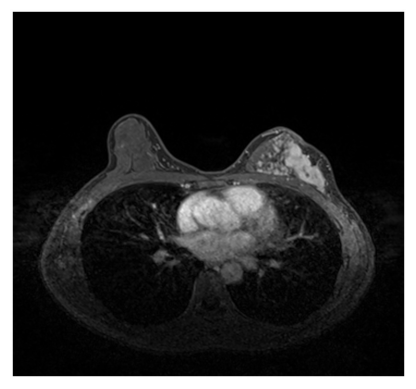

In [45]:
print(image1.shape)
plt.imshow(image1)
plt.axis('off')
plt.show()

(224, 224, 3)


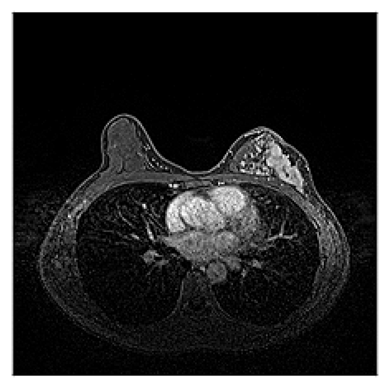

In [61]:
#resizing image1 and sharpening

resized_img1 = cv2.resize(image1, (224, 224), interpolation=cv2.INTER_AREA)
print(resized_img1.shape )

#sharpening
final_image1 = cv2.filter2D(
        resized_img1, 
        ddepth=-1, 
        kernel=kernel, 
        anchor=(-1, -1), 
        delta=0, 
        borderType=cv2.BORDER_DEFAULT)

plt.imshow(final_image1)
plt.axis('off')
plt.show()

In [69]:
new_pred = new_model.predict(np.expand_dims(final_image1, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


In [ ]:
new_image_pred = (new_pred > 0.5).astype('int32')
new_image_pred[0][0]

# We can see the model correctly predicts a maligant tumor (1). 
# This image was extracted from outside of the test set. 

np.int32(1)